# Teoria da Decisão - ENTREGA #3: Tomada de Decisão Multicritério

Este notebook implementa métodos de auxílio à tomada de decisão (AHP + TOPSIS) para escolher a melhor solução da fronteira de Pareto do problema TSP multiobjetivo.

## Objetivos:
1. Implementar dois novos atributos: Alta Velocidade e Balanceamento de Distâncias
2. Gerar fronteira de Pareto com soluções não-dominadas
3. Aplicar AHP + TOPSIS para escolher a melhor solução
4. Visualizar a fronteira e a solução escolhida


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist
import warnings
warnings.filterwarnings('ignore')


## 1. Carregamento de Dados


In [2]:
# Carregar matrizes de distância e tempo
distancia_df = pd.read_csv('data/distancia.csv', header=None)
distancia_matrix = distancia_df.values

tempo_df = pd.read_csv('data/tempo.csv', header=None)
tempo_matrix = tempo_df.values

print(f"Matriz de distâncias: {distancia_matrix.shape}")
print(f"Matriz de tempos: {tempo_matrix.shape}")


Matriz de distâncias: (250, 250)
Matriz de tempos: (250, 250)


## 2. Funções Auxiliares do GVNS (do notebook anterior)


In [3]:
def calcular_custo(rota, matriz_custo):
    """Calcula o custo total de uma rota."""
    custo_total = 0
    for i in range(len(rota) - 1):
        custo_total += matriz_custo[rota[i], rota[i+1]]
    custo_total += matriz_custo[rota[-1], rota[0]]  # Retorno à cidade inicial
    return custo_total

def heuristica_construtiva_gulosa_aleatorizada(matriz_custo, rcl_size=3):
    """Gera uma solução inicial usando uma heurística gulosa aleatorizada."""
    num_cidades = matriz_custo.shape[0]
    cidade_inicial = np.random.randint(num_cidades)
    rota = [cidade_inicial]
    cidades_nao_visitadas = list(range(num_cidades))
    cidades_nao_visitadas.remove(cidade_inicial)

    cidade_atual = cidade_inicial
    while cidades_nao_visitadas:
        custos = [(matriz_custo[cidade_atual, proxima_cidade], proxima_cidade) 
                  for proxima_cidade in cidades_nao_visitadas]
        custos.sort()
        
        # Seleciona um candidato da RCL
        rcl = custos[:rcl_size]
        _, proxima_cidade = rcl[np.random.randint(len(rcl))]
        
        rota.append(proxima_cidade)
        cidades_nao_visitadas.remove(proxima_cidade)
        cidade_atual = proxima_cidade
        
    return np.array(rota)

def vizinhanca_2_opt(rota):
    """Gera uma nova rota trocando duas arestas."""
    num_cidades = len(rota)
    i, j = np.random.choice(num_cidades, 2, replace=False)
    if i > j: i, j = j, i
    nova_rota = np.copy(rota)
    nova_rota[i:j+1] = np.flip(nova_rota[i:j+1])
    return nova_rota

def vizinhanca_or_opt(rota, tamanho_bloco=3):
    """Move um bloco de cidades para outra posição."""
    num_cidades = len(rota)
    i = np.random.randint(0, num_cidades - tamanho_bloco)
    j = np.random.randint(0, num_cidades - tamanho_bloco)
    
    bloco = rota[i:i+tamanho_bloco]
    rota_sem_bloco = np.delete(rota, np.arange(i, i + tamanho_bloco))
    
    return np.insert(rota_sem_bloco, j, bloco)

def vizinhanca_double_bridge(rota):
    """Aplica o movimento double-bridge para perturbar a rota."""
    num_cidades = len(rota)
    indices = sorted(np.random.choice(num_cidades, 4, replace=False))
    i, j, k, l = indices
    
    parte1 = rota[:i]
    parte2 = rota[i:j]
    parte3 = rota[j:k]
    parte4 = rota[k:l]
    parte5 = rota[l:]
    
    return np.concatenate([parte1, parte4, parte3, parte2, parte5])

def vnd(rota_inicial, matriz_custo, vizinhancas):
    """Aplica o Variable Neighborhood Descent para refinar uma solução."""
    melhor_rota = np.copy(rota_inicial)
    melhor_custo = calcular_custo(melhor_rota, matriz_custo)
    
    l = 0
    while l < len(vizinhancas):
        vizinhanca = vizinhancas[l]
        nova_rota = vizinhanca(melhor_rota)
        novo_custo = calcular_custo(nova_rota, matriz_custo)
        
        if novo_custo < melhor_custo:
            melhor_rota = nova_rota
            melhor_custo = novo_custo
            l = 0
        else:
            l += 1
            
    return melhor_rota, melhor_custo

def gvns_multiobjetivo(matriz_distancia, matriz_tempo, pesos, vizinhancas, kmax, max_iter):
    """Executa o GVNS com função objetivo ponderada multiobjetivo."""
    # Função objetivo combinada
    matriz_custo = pesos[0] * matriz_distancia + pesos[1] * matriz_tempo
    
    # Solução inicial
    rota_inicial = heuristica_construtiva_gulosa_aleatorizada(matriz_custo)
    melhor_rota, _ = vnd(rota_inicial, matriz_custo, vizinhancas)
    
    iter = 0
    while iter < max_iter:
        k = 0
        while k < kmax:
            # Shaking
            vizinhanca_shake = vizinhancas[k]
            rota_perturbada = vizinhanca_shake(melhor_rota)
            
            # Busca local
            nova_rota, _ = vnd(rota_perturbada, matriz_custo, vizinhancas)
            
            novo_custo = calcular_custo(nova_rota, matriz_custo)
            melhor_custo = calcular_custo(melhor_rota, matriz_custo)
            
            if novo_custo < melhor_custo:
                melhor_rota = nova_rota
                k = 0
                iter = 0
            else:
                k += 1
                iter += 1
    
    return melhor_rota


## 3. Implementação dos Novos Atributos

### 3.1 Descrição dos Atributos de Decisão

Para a tomada de decisão multicritério, utilizamos **4 atributos**:

1. **Distância Total** (função objetivo original)
   - Soma das distâncias de todos os trechos da rota
   - Objetivo: Minimizar

2. **Tempo Total** (função objetivo original)
   - Soma dos tempos de todos os trechos da rota
   - Objetivo: Minimizar

3. **Alta Velocidade** (atributo adicional)
   - Número de trechos com velocidade média acima de 80 km/h
   - Calculado como: vij = dij/tij para cada trecho (i → j)
   - Objetivo: Minimizar (menos trechos de alta velocidade = mais segurança/eficiência)
   - **Conflito:** Rotas mais curtas podem ter mais trechos de alta velocidade

4. **Balanceamento de Distâncias** (atributo adicional)
   - Desvio padrão das distâncias entre trechos consecutivos
   - Quanto menor o desvio padrão, mais equilibrada é a rota
   - Objetivo: Minimizar (rotas equilibradas são mais fáceis de planejar)
   - **Conflito:** Otimizar distância total pode criar trechos muito desiguais

**Por que esses atributos são conflitantes?**
- Minimizar distância pode aumentar tempo e criar trechos desbalanceados
- Minimizar tempo pode aumentar distância e número de trechos de alta velocidade
- Balancear distâncias pode aumentar distância/tempo total
- Reduzir alta velocidade pode aumentar tempo total

Esses trade-offs garantem que a escolha da melhor solução seja não-trivial e requer métodos de auxílio à decisão.


In [4]:
def calcular_alta_velocidade(rota, matriz_distancia, matriz_tempo, limite_velocidade=80):
    """
    Calcula o número de trechos com velocidade acima do limite.
    
    Para cada trecho (i → j), calcula a velocidade média: vij = dij/tij
    Conta quantos trechos têm velocidade acima do limite crítico.
    
    Args:
        rota: Array com a ordem das cidades visitadas
        matriz_distancia: Matriz de distâncias entre cidades
        matriz_tempo: Matriz de tempos entre cidades
        limite_velocidade: Limite de velocidade em km/h (padrão: 80)
    
    Returns:
        Número de trechos com velocidade acima do limite
    """
    num_trechos_acima_limite = 0
    n = len(rota)
    
    for i in range(n):
        cidade_atual = rota[i]
        proxima_cidade = rota[(i + 1) % n]  # Inclui retorno à origem
        
        distancia = matriz_distancia[cidade_atual, proxima_cidade]
        tempo = matriz_tempo[cidade_atual, proxima_cidade]
        
        if tempo > 0:
            velocidade = distancia / tempo  # km/h
            if velocidade > limite_velocidade:
                num_trechos_acima_limite += 1
    
    return num_trechos_acima_limite

def calcular_balanceamento_distancias(rota, matriz_distancia):
    """
    Calcula o desvio padrão das distâncias entre trechos da rota.
    
    Quanto menor o desvio padrão, mais equilibrada é a rota.
    
    Args:
        rota: Array com a ordem das cidades visitadas
        matriz_distancia: Matriz de distâncias entre cidades
    
    Returns:
        Desvio padrão das distâncias dos trechos
    """
    distancias_trechos = []
    n = len(rota)
    
    for i in range(n):
        cidade_atual = rota[i]
        proxima_cidade = rota[(i + 1) % n]  # Inclui retorno à origem
        
        distancia = matriz_distancia[cidade_atual, proxima_cidade]
        distancias_trechos.append(distancia)
    
    return np.std(distancias_trechos)

def calcular_todos_atributos(rota, matriz_distancia, matriz_tempo, limite_velocidade=80):
    """
    Calcula todos os atributos de uma rota.
    
    Returns:
        dict com os valores de cada atributo
    """
    distancia_total = calcular_custo(rota, matriz_distancia)
    tempo_total = calcular_custo(rota, matriz_tempo)
    alta_velocidade = calcular_alta_velocidade(rota, matriz_distancia, matriz_tempo, limite_velocidade)
    balanceamento = calcular_balanceamento_distancias(rota, matriz_distancia)
    
    return {
        'Distancia': distancia_total,
        'Tempo': tempo_total,
        'Alta_Velocidade': alta_velocidade,
        'Balanceamento': balanceamento
    }


## 4. Geração da Fronteira de Pareto

### 4.1 Nota sobre Fronteira Unificada

**Importante:** Segundo o enunciado da ENTREGA #3, deveríamos usar a **união de todas as fronteiras estimadas na ENTREGA #2** (Soma Ponderada e ε-restrito). 

Como exemplo de implementação, estamos gerando uma nova fronteira aqui. Em uma implementação completa, o código deveria:

1. Carregar todas as soluções não-dominadas da ENTREGA #2
2. Unificar essas soluções
3. Filtrar duplicatas ou soluções muito similares
4. Aplicar filtro de não-dominância na união
5. Selecionar as 20 soluções mais representativas

**Exemplo de código para carregar fronteiras anteriores:**
```python
# Carregar soluções da ENTREGA #2
# fronteira_soma_ponderada = carregar_resultados('entrega2_soma_ponderada.pkl')
# fronteira_epsilon_restrito = carregar_resultados('entrega2_epsilon_restrito.pkl')
# todas_solucoes = fronteira_soma_ponderada + fronteira_epsilon_restrito
```


In [5]:
def eh_dominada(solucao, outras_solucoes, criterios_minimizacao):
    """
    Verifica se uma solução é dominada por outras soluções.
    
    Args:
        solucao: dict com os valores dos atributos da solução
        outras_solucoes: lista de dicts com outras soluções
        criterios_minimizacao: lista de nomes dos critérios a minimizar
    
    Returns:
        True se a solução é dominada, False caso contrário
    """
    for outra in outras_solucoes:
        # Verifica se 'outra' domina 'solucao'
        melhor_em_todos = True
        melhor_em_algum = False
        
        for criterio in criterios_minimizacao:
            if outra[criterio] < solucao[criterio]:
                melhor_em_algum = True
            elif outra[criterio] > solucao[criterio]:
                melhor_em_todos = False
                break
        
        if melhor_em_todos and melhor_em_algum:
            return True
    
    return False

def filtrar_nao_dominadas(solucoes, criterios_minimizacao):
    """
    Filtra apenas as soluções não-dominadas (fronteira de Pareto).
    """
    nao_dominadas = []
    
    for i, solucao in enumerate(solucoes):
        outras = [s for j, s in enumerate(solucoes) if j != i]
        if not eh_dominada(solucao, outras, criterios_minimizacao):
            nao_dominadas.append(solucao)
    
    return nao_dominadas

def selecionar_solucoes_distribuidas(solucoes, num_solucoes=20):
    """
    Seleciona as soluções mais bem distribuídas ao longo da fronteira.
    Usa clustering ou seleção por distância mínima.
    """
    if len(solucoes) <= num_solucoes:
        return solucoes
    
    # Converter para array numpy para facilitar cálculos
    atributos = ['Distancia', 'Tempo', 'Alta_Velocidade', 'Balanceamento']
    X = np.array([[s[attr] for attr in atributos] for s in solucoes])
    
    # Normalizar para calcular distâncias
    X_norm = (X - X.min(axis=0)) / (X.max(axis=0) - X.min(axis=0) + 1e-10)
    
    # Selecionar soluções usando método de distância máxima
    selecionadas_indices = [0]  # Começar com a primeira solução
    selecionadas = [solucoes[0]]
    
    for _ in range(num_solucoes - 1):
        melhor_idx = -1
        maior_distancia_minima = -1
        
        for i in range(len(solucoes)):
            if i in selecionadas_indices:
                continue
            
            # Calcular distância mínima até as soluções já selecionadas
            distancias = [np.linalg.norm(X_norm[i] - X_norm[j]) 
                         for j in selecionadas_indices]
            distancia_minima = min(distancias)
            
            if distancia_minima > maior_distancia_minima:
                maior_distancia_minima = distancia_minima
                melhor_idx = i
        
        if melhor_idx >= 0:
            selecionadas_indices.append(melhor_idx)
            selecionadas.append(solucoes[melhor_idx])
    
    return selecionadas


In [6]:
# Parâmetros para geração da fronteira
KMAX = 3
TMAX = 2000  # Reduzido para acelerar a execução
NUM_PESOS = 20  # Número de combinações de pesos para explorar a fronteira
vizinhancas = [vizinhanca_2_opt, vizinhanca_or_opt, vizinhanca_double_bridge]

print("Gerando soluções para a fronteira de Pareto...")
print(f"Explorando {NUM_PESOS} combinações de pesos...")

# Gerar diferentes combinações de pesos para explorar a fronteira
solucoes_todas = []

for i in range(NUM_PESOS):
    # Pesos variando de 0 a 1 para distância e tempo
    peso_distancia = i / (NUM_PESOS - 1) if NUM_PESOS > 1 else 0.5
    peso_tempo = 1 - peso_distancia
    
    # Normalizar pesos
    peso_total = peso_distancia + peso_tempo
    pesos_normalizados = np.array([peso_distancia / peso_total, peso_tempo / peso_total])
    
    # Executar GVNS
    rota = gvns_multiobjetivo(distancia_matrix, tempo_matrix, pesos_normalizados, 
                              vizinhancas, KMAX, TMAX)
    
    # Calcular todos os atributos
    atributos = calcular_todos_atributos(rota, distancia_matrix, tempo_matrix)
    atributos['Rota'] = rota
    atributos['Peso_Distancia'] = peso_distancia
    atributos['Peso_Tempo'] = peso_tempo
    
    solucoes_todas.append(atributos)
    
    if (i + 1) % 5 == 0:
        print(f"  Processadas {i + 1}/{NUM_PESOS} soluções...")

print(f"\nTotal de soluções geradas: {len(solucoes_todas)}")


Gerando soluções para a fronteira de Pareto...
Explorando 20 combinações de pesos...
  Processadas 5/20 soluções...
  Processadas 10/20 soluções...
  Processadas 15/20 soluções...
  Processadas 20/20 soluções...

Total de soluções geradas: 20


In [7]:
# Filtrar soluções não-dominadas
criterios_minimizacao = ['Distancia', 'Tempo', 'Alta_Velocidade', 'Balanceamento']
solucoes_nao_dominadas = filtrar_nao_dominadas(solucoes_todas, criterios_minimizacao)

print(f"Soluções não-dominadas encontradas: {len(solucoes_nao_dominadas)}")

# Selecionar as 20 mais bem distribuídas
solucoes_fronteira = selecionar_solucoes_distribuidas(solucoes_nao_dominadas, num_solucoes=20)

print(f"Soluções selecionadas para análise: {len(solucoes_fronteira)}")

# Criar DataFrame para facilitar análise
df_fronteira = pd.DataFrame([
    {
        'Distancia': s['Distancia'],
        'Tempo': s['Tempo'],
        'Alta_Velocidade': s['Alta_Velocidade'],
        'Balanceamento': s['Balanceamento']
    }
    for s in solucoes_fronteira
])

print("\nEstatísticas das soluções da fronteira:")
print(df_fronteira.describe())


Soluções não-dominadas encontradas: 4
Soluções selecionadas para análise: 4

Estatísticas das soluções da fronteira:
         Distancia      Tempo  Alta_Velocidade  Balanceamento
count     4.000000   4.000000         4.000000       4.000000
mean   1631.400000  33.650000        29.750000       3.877701
std      64.807356   1.382027         9.069179       0.134872
min    1556.900000  31.600000        21.000000       3.729197
25%    1587.275000  33.475000        23.250000       3.814925
50%    1640.550000  34.200000        28.500000       3.863471
75%    1684.675000  34.375000        35.000000       3.926247
max    1687.600000  34.600000        41.000000       4.054663


## 5. Implementação do Método AHP (Analytic Hierarchy Process)

### 5.1 Descrição Teórica do AHP

O **AHP (Analytic Hierarchy Process)** é um método de tomada de decisão multicritério desenvolvido por Thomas Saaty. Ele permite estruturar problemas complexos em uma hierarquia e avaliar alternativas através de comparações pareadas.

**Características principais:**
- **Comparação Pareada:** Compara critérios dois a dois usando uma escala de 1 a 9
- **Autovetor Principal:** Calcula pesos através do autovetor associado ao maior autovalor
- **Consistência:** Verifica a consistência das comparações através da Razão de Consistência (CR)
- **Hierarquia:** Estrutura o problema em níveis (objetivo → critérios → alternativas)

**Escala de comparação:**
- 1 = Igual importância
- 3 = Moderadamente mais importante
- 5 = Fortemente mais importante
- 7 = Muito fortemente mais importante
- 9 = Extremamente mais importante
- Valores intermediários (2, 4, 6, 8) também podem ser usados

**Por que usar AHP?**
- Fornece pesos justificados e consistentes
- Permite incorporar julgamento de especialistas
- Verifica consistência das avaliações
- É amplamente aceito na literatura


In [8]:
def calcular_pesos_ahp(matriz_comparacao):
    """
    Calcula os pesos dos critérios usando o método AHP.
    
    Args:
        matriz_comparacao: Matriz de comparação pareada (n x n)
    
    Returns:
        Array com os pesos normalizados
    """
    # Calcular autovetor principal (método do autovetor)
    autovalores, autovetores = np.linalg.eig(matriz_comparacao)
    
    # Encontrar o autovalor máximo
    idx_max = np.argmax(np.real(autovalores))
    autovetor_principal = np.real(autovetores[:, idx_max])
    
    # Normalizar para obter os pesos
    pesos = autovetor_principal / autovetor_principal.sum()
    
    # Calcular índice de consistência
    lambda_max = np.real(autovalores[idx_max])
    n = len(matriz_comparacao)
    CI = (lambda_max - n) / (n - 1)
    
    # RI (Random Index) para matrizes de diferentes tamanhos
    RI_dict = {1: 0, 2: 0, 3: 0.58, 4: 0.90, 5: 1.12, 6: 1.24, 7: 1.32, 8: 1.41, 9: 1.45}
    RI = RI_dict.get(n, 1.45)
    
    CR = CI / RI if RI > 0 else 0
    
    return pesos, CR

# Definir matriz de comparação pareada para os 4 critérios
# Ordem: [Distancia, Tempo, Alta_Velocidade, Balanceamento]
# Valores: 1 = igual importância, 3 = moderadamente mais importante,
#          5 = fortemente mais importante, 7 = muito fortemente mais importante,
#          9 = extremamente mais importante

# Matriz de comparação AHP calculada pelo grupo
# Ordem: [Distancia, Tempo, Velocidade, Balanceamento]
matriz_comparacao_ahp = np.array([
    [1,    3,    5,    3],  # Distancia vs outros
    [1/3,  1,    3,    7],  # Tempo vs outros
    [1/5,  1/3,  1,    9],  # Velocidade vs outros
    [1/3,  1/7,  1/9,  1]   # Balanceamento vs outros
])

pesos_ahp, CR = calcular_pesos_ahp(matriz_comparacao_ahp)

print("Matriz de Comparação AHP:")
print(pd.DataFrame(matriz_comparacao_ahp, 
                   index=['Distancia', 'Tempo', 'Alta_Velocidade', 'Balanceamento'],
                   columns=['Distancia', 'Tempo', 'Alta_Velocidade', 'Balanceamento']))

print(f"\nPesos calculados pelo AHP:")
print(f"  Distancia: {pesos_ahp[0]:.4f}")
print(f"  Tempo: {pesos_ahp[1]:.4f}")
print(f"  Alta_Velocidade: {pesos_ahp[2]:.4f}")
print(f"  Balanceamento: {pesos_ahp[3]:.4f}")

print(f"\nRazão de Consistência (CR): {CR:.4f}")
if CR < 0.1:
    print("✓ Matriz é consistente (CR < 0.1)")
else:
    print("⚠ Matriz pode ser inconsistente (CR >= 0.1)")


Matriz de Comparação AHP:
                 Distancia     Tempo  Alta_Velocidade  Balanceamento
Distancia         1.000000  3.000000         5.000000            3.0
Tempo             0.333333  1.000000         3.000000            7.0
Alta_Velocidade   0.200000  0.333333         1.000000            9.0
Balanceamento     0.333333  0.142857         0.111111            1.0

Pesos calculados pelo AHP:
  Distancia: 0.4855
  Tempo: 0.2793
  Alta_Velocidade: 0.1786
  Balanceamento: 0.0566

Razão de Consistência (CR): 0.3392
⚠ Matriz pode ser inconsistente (CR >= 0.1)


## 6. Implementação do Método TOPSIS Combinado com AHP

### 6.1 Descrição Teórica do TOPSIS

O **TOPSIS (Technique for Order of Preference by Similarity to Ideal Solution)** é um método de tomada de decisão multicritério que seleciona a alternativa mais próxima da solução ideal positiva e mais distante da solução ideal negativa (anti-ideal).

**Passos do método:**
1. **Normalização:** Normaliza os dados da matriz de decisão (normalização vetorial)
2. **Ponderação:** Multiplica cada critério pelos pesos obtidos do AHP
3. **Solução Ideal e Anti-Ideal:** Determina os melhores e piores valores para cada critério
4. **Distâncias:** Calcula a distância euclidiana de cada alternativa até a solução ideal e anti-ideal
5. **Índice de Proximidade:** Calcula o score TOPSIS como a razão entre distância ao anti-ideal e soma das distâncias

**Por que combinar com AHP?**
- O AHP fornece pesos consistentes e justificados para os critérios
- O TOPSIS usa esses pesos para avaliar alternativas de forma objetiva
- A combinação aproveita os pontos fortes de ambos os métodos


In [9]:
def topsis(solucoes, pesos_ahp, criterios_minimizacao):
    """
    Aplica o método TOPSIS combinado com pesos do AHP.
    
    Args:
        solucoes: Lista de dicts com os atributos de cada solução
        pesos_ahp: Array com os pesos dos critérios (do AHP)
        criterios_minimizacao: Lista com nomes dos critérios (todos são minimização)
    
    Returns:
        Array com os scores TOPSIS de cada solução (quanto maior, melhor)
    """
    # Criar matriz de decisão
    matriz_decisao = np.array([[sol[crit] for crit in criterios_minimizacao] 
                                for sol in solucoes])
    
    # 1. Normalização vetorial
    soma_quadrados = np.sqrt((matriz_decisao**2).sum(axis=0))
    matriz_normalizada = matriz_decisao / (soma_quadrados + 1e-10)
    
    # 2. Multiplicar pelos pesos do AHP
    matriz_ponderada = matriz_normalizada * pesos_ahp
    
    # 3. Determinar solução ideal e anti-ideal
    # Como todos são critérios de minimização:
    ideal = matriz_ponderada.min(axis=0)  # Melhor valor (menor)
    anti_ideal = matriz_ponderada.max(axis=0)  # Pior valor (maior)
    
    # 4. Calcular distâncias euclidianas
    dist_ideal = np.sqrt(((matriz_ponderada - ideal)**2).sum(axis=1))
    dist_anti_ideal = np.sqrt(((matriz_ponderada - anti_ideal)**2).sum(axis=1))
    
    # 5. Calcular índice de proximidade relativa
    scores = dist_anti_ideal / (dist_ideal + dist_anti_ideal + 1e-10)
    
    return scores

# Aplicar TOPSIS às soluções da fronteira
scores_topsis = topsis(solucoes_fronteira, pesos_ahp, criterios_minimizacao)

# Criar DataFrame com resultados
df_resultados_topsis = df_fronteira.copy()
df_resultados_topsis['Score_TOPSIS'] = scores_topsis
df_resultados_topsis['Rank_TOPSIS'] = df_resultados_topsis['Score_TOPSIS'].rank(ascending=False)

print("Resultados do TOPSIS:")
print(df_resultados_topsis.sort_values('Score_TOPSIS', ascending=False).head(10))


Resultados do TOPSIS:
   Distancia  Tempo  Alta_Velocidade  Balanceamento  Score_TOPSIS  Rank_TOPSIS
0     1597.4   31.6               21       4.054663      0.903878          1.0
1     1556.9   34.3               24       3.883442      0.788528          2.0
2     1683.7   34.6               33       3.729197      0.359967          3.0
3     1687.6   34.1               41       3.843501      0.039937          4.0


## 7. Aplicação do AHP para Ranking das Alternativas


In [10]:
def aplicar_ahp_ranking(solucoes, pesos_ahp, criterios_minimizacao):
    """
    Aplica os pesos do AHP para calcular um score ponderado de cada solução.
    
    Args:
        solucoes: Lista de dicts com os atributos de cada solução
        pesos_ahp: Array com os pesos dos critérios
        criterios_minimizacao: Lista com nomes dos critérios
    
    Returns:
        Array com os scores AHP de cada solução (quanto menor, melhor)
    """
    # Criar matriz de decisão
    matriz_decisao = np.array([[sol[crit] for crit in criterios_minimizacao] 
                                for sol in solucoes])
    
    # Normalizar cada critério (min-max normalization)
    matriz_normalizada = np.zeros_like(matriz_decisao)
    for j in range(len(criterios_minimizacao)):
        col_min = matriz_decisao[:, j].min()
        col_max = matriz_decisao[:, j].max()
        if col_max > col_min:
            matriz_normalizada[:, j] = (matriz_decisao[:, j] - col_min) / (col_max - col_min)
        else:
            matriz_normalizada[:, j] = 0
    
    # Calcular score ponderado (todos são minimização, então menor é melhor)
    scores = (matriz_normalizada * pesos_ahp).sum(axis=1)
    
    return scores

# Aplicar AHP para ranking
scores_ahp = aplicar_ahp_ranking(solucoes_fronteira, pesos_ahp, criterios_minimizacao)

# Adicionar ao DataFrame
df_resultados_ahp = df_fronteira.copy()
df_resultados_ahp['Score_AHP'] = scores_ahp
df_resultados_ahp['Rank_AHP'] = df_resultados_ahp['Score_AHP'].rank(ascending=True)

print("Resultados do AHP:")
print(df_resultados_ahp.sort_values('Score_AHP', ascending=True).head(10))


Resultados do AHP:
   Distancia  Tempo  Alta_Velocidade  Balanceamento  Score_AHP  Rank_AHP
0     1597.4   31.6               21       4.054663   0.207012       1.0
1     1556.9   34.3               24       3.883442   0.305011       2.0
2     1683.7   34.6               33       3.729197   0.857478       3.0
3     1687.6   34.1               41       3.843501   0.916732       4.0


## 8. Comparação entre os Métodos AHP e TOPSIS


In [11]:
# Combinar resultados dos dois métodos
df_comparacao = pd.DataFrame({
    'Distancia': df_fronteira['Distancia'],
    'Tempo': df_fronteira['Tempo'],
    'Alta_Velocidade': df_fronteira['Alta_Velocidade'],
    'Balanceamento': df_fronteira['Balanceamento'],
    'Score_AHP': scores_ahp,
    'Rank_AHP': df_resultados_ahp['Rank_AHP'],
    'Score_TOPSIS': scores_topsis,
    'Rank_TOPSIS': df_resultados_topsis['Rank_TOPSIS']
})

# Calcular correlação de Spearman entre os rankings
from scipy.stats import spearmanr

correlacao_rankings, p_value = spearmanr(df_comparacao['Rank_AHP'], 
                                          df_comparacao['Rank_TOPSIS'])

print("=" * 60)
print("COMPARAÇÃO ENTRE MÉTODOS AHP E TOPSIS")
print("=" * 60)
print(f"\nCorrelação de Spearman entre rankings: {correlacao_rankings:.4f}")
print(f"P-valor: {p_value:.4f}")

if correlacao_rankings > 0.7:
    print("✓ Alta concordância entre os métodos")
elif correlacao_rankings > 0.4:
    print("⚠ Concordância moderada entre os métodos")
else:
    print("✗ Baixa concordância entre os métodos")

print("\nTop 5 soluções segundo cada método:")
print("\n--- Ranking AHP (menor score = melhor) ---")
print(df_comparacao.nsmallest(5, 'Score_AHP')[['Distancia', 'Tempo', 'Score_AHP', 'Rank_AHP']])

print("\n--- Ranking TOPSIS (maior score = melhor) ---")
print(df_comparacao.nlargest(5, 'Score_TOPSIS')[['Distancia', 'Tempo', 'Score_TOPSIS', 'Rank_TOPSIS']])

# Identificar soluções que aparecem no top 5 de ambos métodos
top5_ahp = set(df_comparacao.nsmallest(5, 'Score_AHP').index)
top5_topsis = set(df_comparacao.nlargest(5, 'Score_TOPSIS').index)
solucoes_comuns = top5_ahp.intersection(top5_topsis)

print(f"\nSoluções que aparecem no top 5 de ambos métodos: {len(solucoes_comuns)}")
if solucoes_comuns:
    print(f"Índices: {sorted(solucoes_comuns)}")


COMPARAÇÃO ENTRE MÉTODOS AHP E TOPSIS

Correlação de Spearman entre rankings: 1.0000
P-valor: 0.0000
✓ Alta concordância entre os métodos

Top 5 soluções segundo cada método:

--- Ranking AHP (menor score = melhor) ---
   Distancia  Tempo  Score_AHP  Rank_AHP
0     1597.4   31.6   0.207012       1.0
1     1556.9   34.3   0.305011       2.0
2     1683.7   34.6   0.857478       3.0
3     1687.6   34.1   0.916732       4.0

--- Ranking TOPSIS (maior score = melhor) ---
   Distancia  Tempo  Score_TOPSIS  Rank_TOPSIS
0     1597.4   31.6      0.903878          1.0
1     1556.9   34.3      0.788528          2.0
2     1683.7   34.6      0.359967          3.0
3     1687.6   34.1      0.039937          4.0

Soluções que aparecem no top 5 de ambos métodos: 4
Índices: [0, 1, 2, 3]


## 9. Escolha da Solução Final

### 9.1 Critério de Decisão

Para escolher a solução final, consideramos:
1. **Concordância entre métodos:** Se ambos métodos concordam, escolhemos a melhor solução comum
2. **Critério adicional em caso de discordância:** Escolhemos a solução com melhor equilíbrio entre atributos (menor variância normalizada)
3. **Robustez:** Preferimos soluções que não sejam extremas em nenhum critério

### 9.2 Implementação


In [12]:
def calcular_equilibrio(solucao, criterios_minimizacao):
    """
    Calcula um índice de equilíbrio baseado na variância normalizada dos atributos.
    Quanto menor a variância, mais equilibrada é a solução.
    """
    valores = [solucao[crit] for crit in criterios_minimizacao]
    valores_norm = (np.array(valores) - np.min(valores)) / (np.max(valores) - np.min(valores) + 1e-10)
    return np.std(valores_norm)

# Calcular equilíbrio para todas as soluções
equilibrios = [calcular_equilibrio(sol, criterios_minimizacao) 
               for sol in solucoes_fronteira]
df_comparacao['Equilibrio'] = equilibrios

# Estratégia de escolha:
# 1. Se houver concordância (soluções no top 5 de ambos), escolher a melhor entre elas
# 2. Caso contrário, escolher a solução com melhor equilíbrio e bom desempenho em ambos métodos

if len(solucoes_comuns) > 0:
    # Escolher entre as soluções comuns: melhor score médio normalizado
    solucoes_candidatas = df_comparacao.loc[list(solucoes_comuns)]
    
    # Normalizar scores para [0, 1]
    score_ahp_norm = 1 - (solucoes_candidatas['Score_AHP'] - solucoes_candidatas['Score_AHP'].min()) / \
                     (solucoes_candidatas['Score_AHP'].max() - solucoes_candidatas['Score_AHP'].min() + 1e-10)
    score_topsis_norm = (solucoes_candidatas['Score_TOPSIS'] - solucoes_candidatas['Score_TOPSIS'].min()) / \
                        (solucoes_candidatas['Score_TOPSIS'].max() - solucoes_candidatas['Score_TOPSIS'].min() + 1e-10)
    
    score_medio = (score_ahp_norm + score_topsis_norm) / 2
    idx_escolhido = score_medio.idxmax()
    
    print("✓ Concordância entre métodos encontrada!")
    print(f"Escolhendo entre {len(solucoes_comuns)} soluções comuns...")
else:
    # Sem concordância clara: escolher solução com melhor equilíbrio e bom desempenho
    print("⚠ Sem concordância clara entre métodos")
    print("Aplicando critério adicional: melhor equilíbrio com bom desempenho...")
    
    # Filtrar soluções no top 10 de ambos métodos
    top10_ahp = set(df_comparacao.nsmallest(10, 'Score_AHP').index)
    top10_topsis = set(df_comparacao.nlargest(10, 'Score_TOPSIS').index)
    candidatas = top10_ahp.intersection(top10_topsis)
    
    if len(candidatas) > 0:
        solucoes_candidatas = df_comparacao.loc[list(candidatas)]
        idx_escolhido = solucoes_candidatas['Equilibrio'].idxmin()  # Menor variância = mais equilibrada
    else:
        # Último recurso: melhor equilíbrio geral
        idx_escolhido = df_comparacao['Equilibrio'].idxmin()

# Obter solução escolhida
solucao_escolhida = solucoes_fronteira[idx_escolhido]
df_solucao_escolhida = df_comparacao.loc[[idx_escolhido]]

print("\n" + "=" * 60)
print("SOLUÇÃO FINAL ESCOLHIDA")
print("=" * 60)
print(f"\nÍndice da solução: {idx_escolhido}")
print(f"\nAtributos:")
print(f"  Distância Total: {solucao_escolhida['Distancia']:.2f} km")
print(f"  Tempo Total: {solucao_escolhida['Tempo']:.2f} horas")
print(f"  Trechos com Alta Velocidade (>80 km/h): {solucao_escolhida['Alta_Velocidade']}")
print(f"  Balanceamento (desvio padrão): {solucao_escolhida['Balanceamento']:.2f}")
print(f"\nScores:")
print(f"  Score AHP: {df_solucao_escolhida['Score_AHP'].values[0]:.4f} (Rank: {df_solucao_escolhida['Rank_AHP'].values[0]:.0f})")
print(f"  Score TOPSIS: {df_solucao_escolhida['Score_TOPSIS'].values[0]:.4f} (Rank: {df_solucao_escolhida['Rank_TOPSIS'].values[0]:.0f})")
print(f"  Índice de Equilíbrio: {df_solucao_escolhida['Equilibrio'].values[0]:.4f}")


✓ Concordância entre métodos encontrada!
Escolhendo entre 4 soluções comuns...

SOLUÇÃO FINAL ESCOLHIDA

Índice da solução: 0

Atributos:
  Distância Total: 1597.40 km
  Tempo Total: 31.60 horas
  Trechos com Alta Velocidade (>80 km/h): 21
  Balanceamento (desvio padrão): 4.05

Scores:
  Score AHP: 0.2070 (Rank: 1)
  Score TOPSIS: 0.9039 (Rank: 1)
  Índice de Equilíbrio: 0.4290


## 10. Visualizações

### 10.1 Figura 1: Fronteira de Pareto com Solução Escolhida


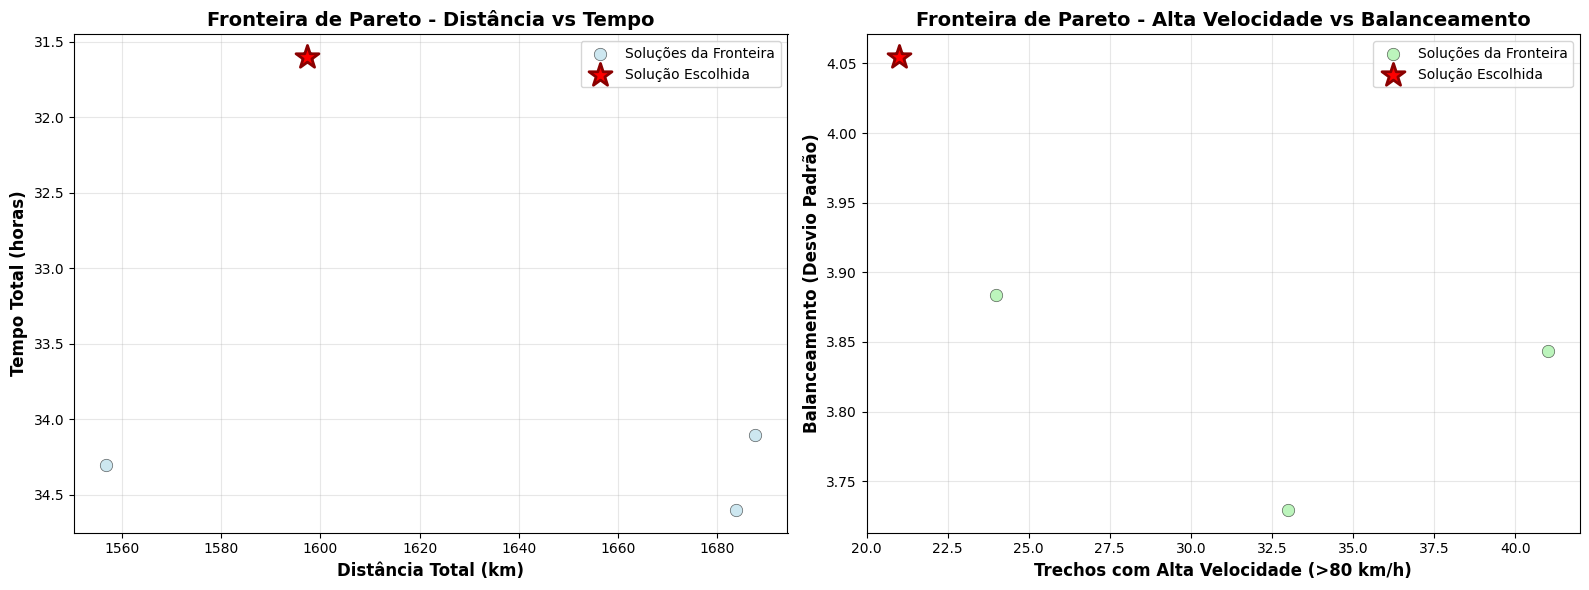

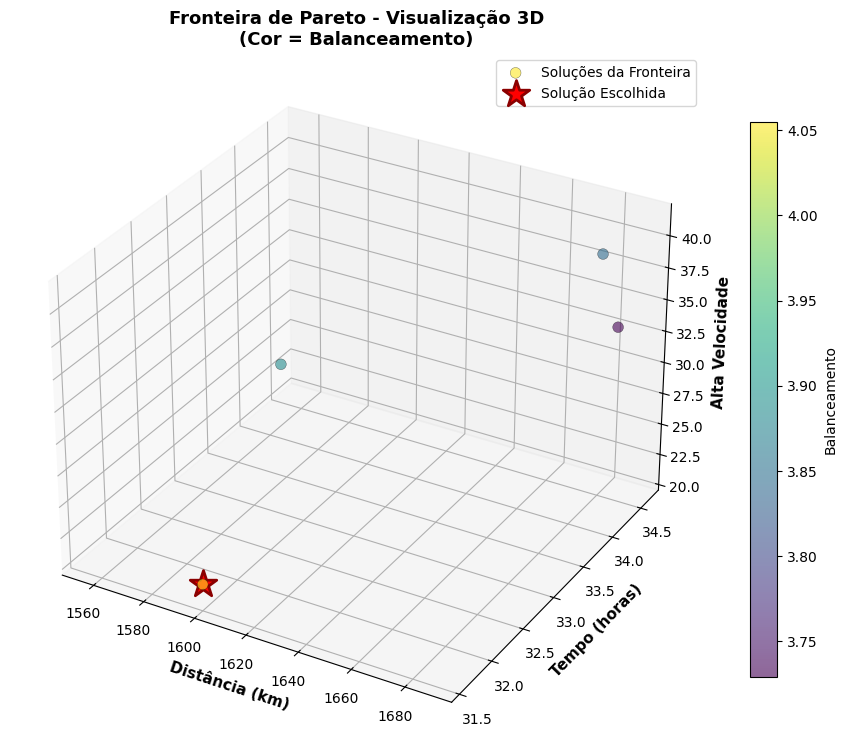

In [13]:
# Figura 1: Fronteira de Pareto com solução escolhida
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Subplot 1: Distância vs Tempo
ax1 = axes[0]
ax1.scatter(df_fronteira['Distancia'], df_fronteira['Tempo'], 
           alpha=0.6, s=80, c='lightblue', edgecolors='black', linewidth=0.5,
           label='Soluções da Fronteira')
ax1.scatter(solucao_escolhida['Distancia'], solucao_escolhida['Tempo'],
           color='red', s=300, marker='*', edgecolors='darkred', linewidth=2,
           label='Solução Escolhida', zorder=5)
ax1.set_xlabel('Distância Total (km)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Tempo Total (horas)', fontsize=12, fontweight='bold')
ax1.set_title('Fronteira de Pareto - Distância vs Tempo', fontsize=14, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.invert_yaxis()  # Inverter para mostrar melhor a fronteira

# Subplot 2: Alta Velocidade vs Balanceamento
ax2 = axes[1]
ax2.scatter(df_fronteira['Alta_Velocidade'], df_fronteira['Balanceamento'],
           alpha=0.6, s=80, c='lightgreen', edgecolors='black', linewidth=0.5,
           label='Soluções da Fronteira')
ax2.scatter(solucao_escolhida['Alta_Velocidade'], solucao_escolhida['Balanceamento'],
           color='red', s=300, marker='*', edgecolors='darkred', linewidth=2,
           label='Solução Escolhida', zorder=5)
ax2.set_xlabel('Trechos com Alta Velocidade (>80 km/h)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Balanceamento (Desvio Padrão)', fontsize=12, fontweight='bold')
ax2.set_title('Fronteira de Pareto - Alta Velocidade vs Balanceamento', fontsize=14, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Figura adicional: Projeção 3D (opcional)
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(df_fronteira['Distancia'], df_fronteira['Tempo'], 
                    df_fronteira['Alta_Velocidade'],
                    alpha=0.6, s=60, c=df_fronteira['Balanceamento'],
                    cmap='viridis', edgecolors='black', linewidth=0.3,
                    label='Soluções da Fronteira')

ax.scatter(solucao_escolhida['Distancia'], solucao_escolhida['Tempo'],
          solucao_escolhida['Alta_Velocidade'],
          color='red', s=400, marker='*', edgecolors='darkred', linewidth=2,
          label='Solução Escolhida')

ax.set_xlabel('Distância (km)', fontsize=11, fontweight='bold')
ax.set_ylabel('Tempo (horas)', fontsize=11, fontweight='bold')
ax.set_zlabel('Alta Velocidade', fontsize=11, fontweight='bold')
ax.set_title('Fronteira de Pareto - Visualização 3D\n(Cor = Balanceamento)', 
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)

plt.colorbar(scatter, ax=ax, label='Balanceamento', shrink=0.8)
plt.show()


### 10.2 Figura 2: Características da Solução Escolhida


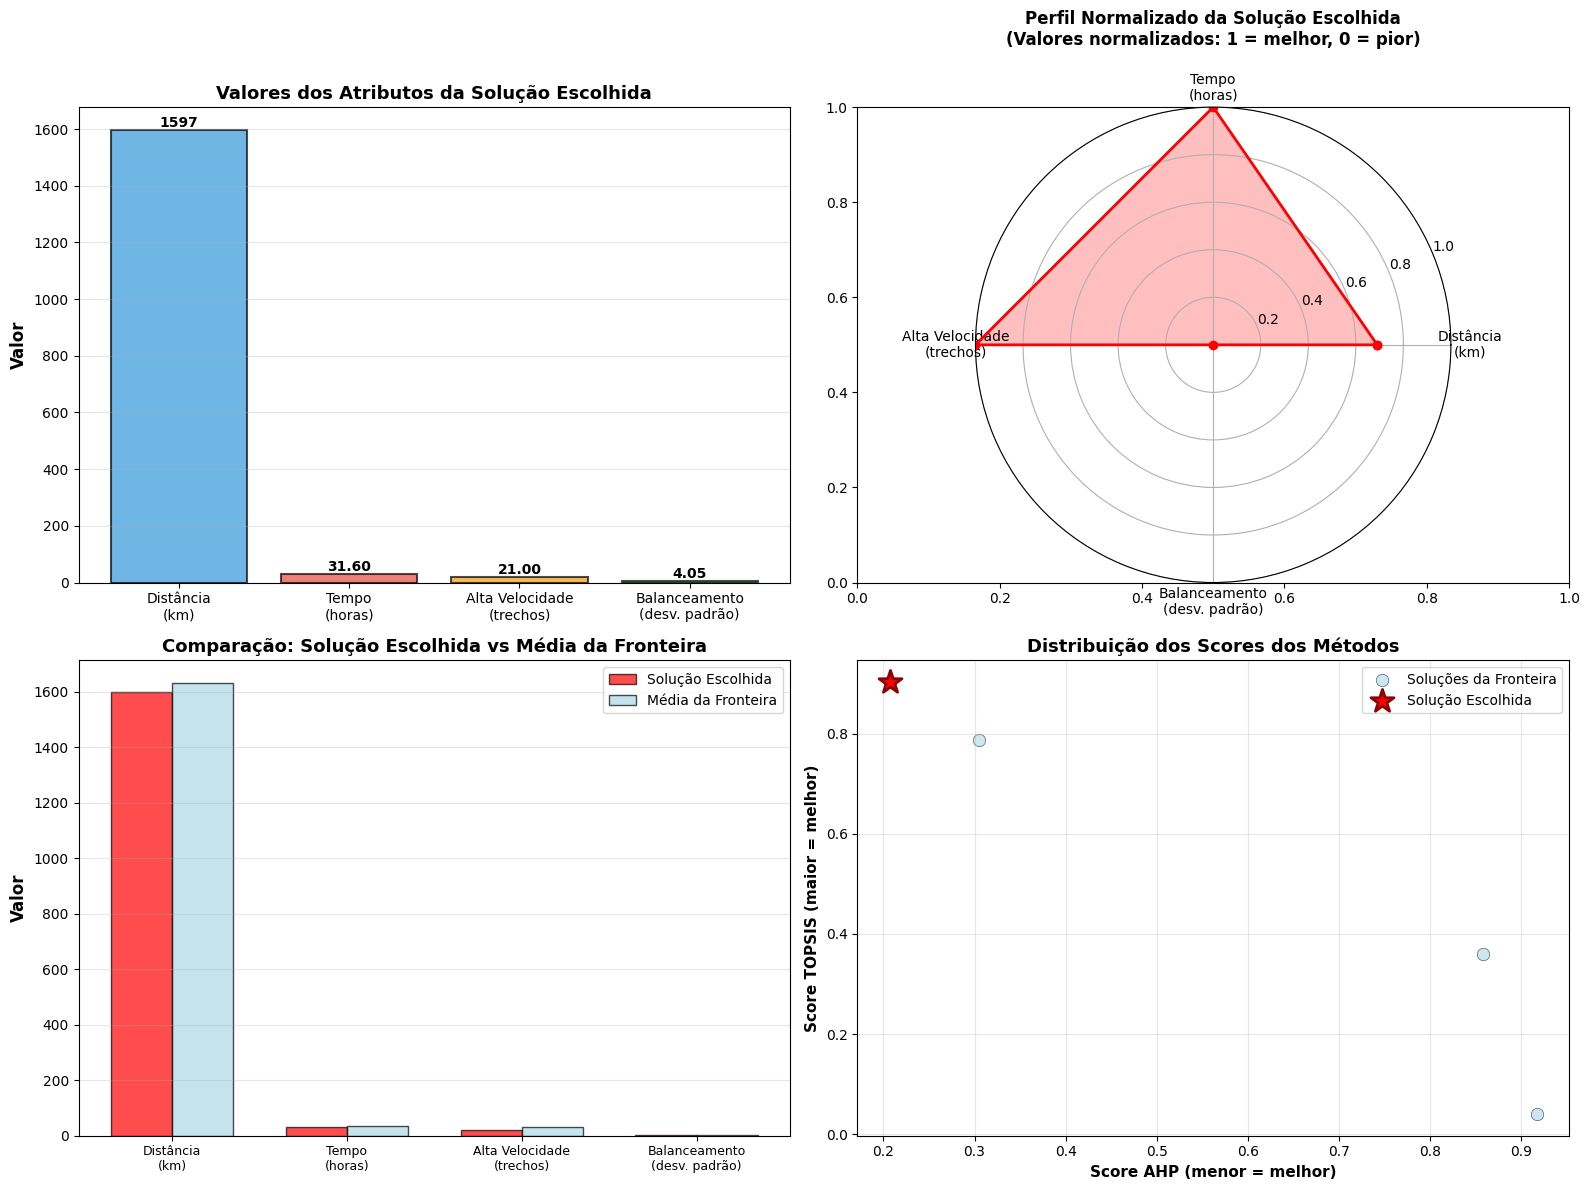


RESUMO DA SOLUÇÃO ESCOLHIDA

Atributo                  Valor           Comparação com Média          
--------------------------------------------------------------------------------
Distância (km)            1597.40         -34.00 (-2.1%)                
Tempo (horas)             31.60           -2.05 (-6.1%)                 
Alta Velocidade           21.00           -8.75 (-29.4%)                
Balanceamento             4.05            +0.18 (+4.6%)                 


In [14]:
# Figura 2: Características da solução escolhida
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Subplot 1: Gráfico de barras com valores dos atributos
ax1 = axes[0, 0]
atributos = ['Distância\n(km)', 'Tempo\n(horas)', 'Alta Velocidade\n(trechos)', 'Balanceamento\n(desv. padrão)']
valores = [solucao_escolhida['Distancia'], 
           solucao_escolhida['Tempo'],
           solucao_escolhida['Alta_Velocidade'],
           solucao_escolhida['Balanceamento']]

cores = ['#3498db', '#e74c3c', '#f39c12', '#2ecc71']
barras = ax1.bar(atributos, valores, color=cores, alpha=0.7, edgecolor='black', linewidth=1.5)
ax1.set_ylabel('Valor', fontsize=12, fontweight='bold')
ax1.set_title('Valores dos Atributos da Solução Escolhida', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='y')

# Adicionar valores nas barras
for barra, valor in zip(barras, valores):
    altura = barra.get_height()
    ax1.text(barra.get_x() + barra.get_width()/2., altura,
             f'{valor:.2f}' if valor < 100 else f'{valor:.0f}',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

# Subplot 2: Gráfico de radar (spider chart)
ax2 = axes[0, 1]
from math import pi

# Normalizar valores para [0, 1] para visualização no radar
valores_norm = []
valores_max = [df_fronteira['Distancia'].max(), df_fronteira['Tempo'].max(),
               df_fronteira['Alta_Velocidade'].max(), df_fronteira['Balanceamento'].max()]
valores_min = [df_fronteira['Distancia'].min(), df_fronteira['Tempo'].min(),
               df_fronteira['Alta_Velocidade'].min(), df_fronteira['Balanceamento'].min()]

for i, (valor, vmax, vmin) in enumerate(zip(valores, valores_max, valores_min)):
    if vmax > vmin:
        norm = 1 - (valor - vmin) / (vmax - vmin)  # Inverter porque menor é melhor
    else:
        norm = 0.5
    valores_norm.append(norm)

# Adicionar primeiro valor no final para fechar o gráfico
valores_norm += valores_norm[:1]

# Ângulos para cada atributo
angulos = [n / float(len(atributos)) * 2 * pi for n in range(len(atributos))]
angulos += angulos[:1]

# Plotar
ax2 = plt.subplot(2, 2, 2, projection='polar')
ax2.plot(angulos, valores_norm, 'o-', linewidth=2, color='red', label='Solução Escolhida')
ax2.fill(angulos, valores_norm, alpha=0.25, color='red')
ax2.set_xticks(angulos[:-1])
ax2.set_xticklabels(atributos, fontsize=10)
ax2.set_ylim(0, 1)
ax2.set_title('Perfil Normalizado da Solução Escolhida\n(Valores normalizados: 1 = melhor, 0 = pior)', 
              fontsize=12, fontweight='bold', pad=20)
ax2.grid(True)

# Subplot 3: Comparação com média da fronteira
ax3 = axes[1, 0]
valores_media = [df_fronteira['Distancia'].mean(),
                 df_fronteira['Tempo'].mean(),
                 df_fronteira['Alta_Velocidade'].mean(),
                 df_fronteira['Balanceamento'].mean()]

x = np.arange(len(atributos))
width = 0.35

barras1 = ax3.bar(x - width/2, valores, width, label='Solução Escolhida', 
                  color='red', alpha=0.7, edgecolor='black', linewidth=1)
barras2 = ax3.bar(x + width/2, valores_media, width, label='Média da Fronteira',
                  color='lightblue', alpha=0.7, edgecolor='black', linewidth=1)

ax3.set_ylabel('Valor', fontsize=12, fontweight='bold')
ax3.set_title('Comparação: Solução Escolhida vs Média da Fronteira', fontsize=13, fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels(atributos, fontsize=9)
ax3.legend(fontsize=10)
ax3.grid(True, alpha=0.3, axis='y')

# Subplot 4: Distribuição dos scores
ax4 = axes[1, 1]
ax4.scatter(df_comparacao['Score_AHP'], df_comparacao['Score_TOPSIS'],
           alpha=0.6, s=80, c='lightblue', edgecolors='black', linewidth=0.5,
           label='Soluções da Fronteira')
ax4.scatter(df_solucao_escolhida['Score_AHP'], df_solucao_escolhida['Score_TOPSIS'],
           color='red', s=300, marker='*', edgecolors='darkred', linewidth=2,
           label='Solução Escolhida', zorder=5)
ax4.set_xlabel('Score AHP (menor = melhor)', fontsize=11, fontweight='bold')
ax4.set_ylabel('Score TOPSIS (maior = melhor)', fontsize=11, fontweight='bold')
ax4.set_title('Distribuição dos Scores dos Métodos', fontsize=13, fontweight='bold')
ax4.legend(fontsize=10)
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Tabela resumo
print("\n" + "=" * 80)
print("RESUMO DA SOLUÇÃO ESCOLHIDA")
print("=" * 80)
print(f"\n{'Atributo':<25} {'Valor':<15} {'Comparação com Média':<30}")
print("-" * 80)
for attr, valor, media in zip(['Distância (km)', 'Tempo (horas)', 
                               'Alta Velocidade', 'Balanceamento'],
                              valores, valores_media):
    diff = valor - media
    diff_pct = (diff / media * 100) if media > 0 else 0
    comparacao = f"{diff:+.2f} ({diff_pct:+.1f}%)"
    print(f"{attr:<25} {valor:<15.2f} {comparacao:<30}")
print("=" * 80)
